# PFM: Machine Learning - Módulo de Fidelización y Recompra
## Fase 1: Análisis Exploratorio de Datos (EDA) y Limpieza de Calidad

**Contexto del Proyecto:** Este Notebook contiene la primera etapa del proyecto de fin de módulo. El objetivo principal es cargar el dataset histórico de transacciones *Online Retail II* (que abarca desde diciembre de 2009 hasta diciembre de 2011), analizar la calidad de la información, gestionar los valores nulos, corregir anomalías o outliers, y unificar las dos hojas de cálculo en un único archivo maestro optimizado para la fase de modelado.

---

### Índice de la Fase 1:
1. **Configuración Inicial e Importación de Librerías**
2. **Carga y Unificación Eficiente del Dataset (Dos Hojas)**
3. **Inspección Inicial y Tipos de Datos**
4. **Análisis de Calidad de Datos (Nulos y Duplicados)**
5. **Limpieza de Datos (Cancelaciones, Precios y Cantidades)**
6. **Exportación del Dataset Limpio a Formato Parquet**

## 1. Configuración Inicial e Importación de Librerías

En esta sección prepararemos el entorno de trabajo importando todas las herramientas necesarias para la manipulación, limpieza y visualización de los datos. Además, estableceremos configuraciones globales en Pandas para asegurar que las visualizaciones de las tablas informativas sean cómodas y no se recorten las columnas en pantalla.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración global de visualización en Pandas
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Configuración básica para los gráficos
plt.style.use('ggplot')
sns.set_palette('husl')

print("Librerías cargadas y entorno configurado correctamente.\n")

Librerías cargadas y entorno configurado correctamente.



## 2. Carga y Unificación Eficiente del Dataset (Dos Hojas)

El conjunto de datos original `online_retail_II.xlsx` se encuentra dividido en dos hojas de cálculo independientes debido al histórico de años correspondientes (diciembre 2009 - diciembre 2010 y diciembre 2010 - diciembre 2011). 

Dado que el archivo original en formato Excel supera el millón de registros, su lectura directa consume una gran cantidad de tiempo y memoria. En este apartado realizaremos los siguientes pasos de forma secuencial:
1. Definir las rutas relativas correctas hacia el archivo fuente dentro de nuestra estructura.
2. Leer ambas hojas de forma explícita utilizando el motor `openpyxl`.
3. Concatenar ambas estructuras en un único DataFrame maestro indexado correctamente.

In [2]:
# Definimos la ruta relativa al archivo Excel 
# (El notebook está en la carpeta 'notebooks', por lo que subimos un nivel con '..')
DATA_PATH = '../data/raw/online_retail_II.xlsx'

try:
    print("Cargando la primera hoja (Año 2009-2010)... Este proceso puede tardar un poco.")
    df1 = pd.read_excel(DATA_PATH, sheet_name=0, engine='openpyxl')
    
    print("Cargando la segunda hoja (Año 2010-2011)...")
    df2 = pd.read_excel(DATA_PATH, sheet_name=1, engine='openpyxl')
    
    # Unificamos ambos dataframes
    df_raw = pd.concat([df1, df2], ignore_index=True)
    
    print("\n¡Carga unificada completada con éxito!")
    print(f"Dimensiones del dataset maestro: {df_raw.shape[0]:,} filas y {df_raw.shape[1]} columnas.")
    
except FileNotFoundError:
    print(f"Error: No se ha encontrado el archivo en la ruta especificada ({DATA_PATH}).")
    print("Por favor, asegúrate de que el archivo online_retail_II.xlsx esté dentro de la carpeta data/raw/\n")

Cargando la primera hoja (Año 2009-2010)... Este proceso puede tardar un poco.
Cargando la segunda hoja (Año 2010-2011)...

¡Carga unificada completada con éxito!
Dimensiones del dataset maestro: 1,067,371 filas y 8 columnas.


## 3. Inspección Inicial y Tipos de Datos

Una vez unificado el conjunto de datos, es fundamental realizar una primera inspección visual y técnica para comprender la naturaleza de las variables con las que vamos a trabajar. 

En este paso ejecutaremos las siguientes acciones:
* Visualizar las primeras filas del dataset para contextualizar la estructura de las facturas (transacciones).
* Obtener el resumen técnico de las columnas y los tipos de datos inferidos (para detectar posibles problemas de formato, como fechas leídas como texto).
* Generar estadísticas descriptivas básicas de las variables numéricas para tener una primera intuición sobre las cantidades compradas y los precios unitarios.

In [3]:
from IPython.display import display

print("1. muestra de las primeras 10 transacciones:")
display(df_raw.head(10))

print("\n2. información técnica del dataset:")
# info() imprime directamente en consola, no necesita display()
df_raw.info() 

print("\n3. estadísticas descriptivas (variables numéricas):")
display(df_raw.describe())

print("\n4. estadísticas descriptivas (variables categóricas/fechas):")
display(df_raw.describe(include=['object', 'datetime64']))

1. muestra de las primeras 10 transacciones:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom



2. información técnica del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB

3. estadísticas descriptivas (variables numéricas):


,Quantity,InvoiceDate,Price,Customer ID
count,1067371.00,1067371,1067371.00,824364.00
mean,9.94,2011-01-02 21:13:55.394029,4.65,15324.64
min,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-07-09 09:46:00,1.25,13975.00
50%,3.00,2010-12-07 15:28:00,2.10,15255.00
75%,10.00,2011-07-22 10:23:00,4.15,16797.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,172.71,NaN,123.55,1697.46



4. estadísticas descriptivas (variables categóricas/fechas):


C:\Users\andre\AppData\Local\Temp\ipykernel_12172\849453556.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_raw.describe(include=['object', 'datetime64']))


,Invoice,StockCode,Description,InvoiceDate,Country
count,1067371.00,1067371,1062989,1067371,1067371
unique,53628.00,5305,5698,NaN,43
top,537434.00,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,United Kingdom
freq,1350.00,5829,5918,NaN,981330
mean,NaN,NaN,NaN,2011-01-02 21:13:55.394029,NaN
min,NaN,NaN,NaN,2009-12-01 07:45:00,NaN
25%,NaN,NaN,NaN,2010-07-09 09:46:00,NaN
50%,NaN,NaN,NaN,2010-12-07 15:28:00,NaN
75%,NaN,NaN,NaN,2011-07-22 10:23:00,NaN
max,NaN,NaN,NaN,2011-12-09 12:50:00,NaN


> ### 🔍 Notas de Análisis y Alertas Críticas (Insights del EDA Inicial)
>
> Tras analizar las estadísticas descriptivas avanzadas y la distribución de los datos, el equipo de Data Science ha identificado tres anomalías críticas en el dataset unificado que requieren una estrategia de tratamiento obligatoria antes del modelado:
>
> 1. **Cancelaciones Simétricas de Gran Volumen (Outliers):** Se detecta un volumen máximo idéntico en positivo y negativo (`Quantity = 80,995` y `-80,995`). Esto evidencia transacciones mayoristas masivas que fueron canceladas en su totalidad. Dejarlas sin un proceso de casación sesgará el patrón de compra real de estos clientes.
> 2. **Precios Unitarios Negativos Anómalos (`Price < 0`):** El valor mínimo desciende hasta `-53,594.36`. En la lógica comercial, un precio unitario negativo no representa una venta ni una devolución estándar, sino ajustes contables manuales internos, correcciones de saldos o incidencias fiscales que deben ser excluidas por completo para no adulterar el cálculo del *revenue*.
> 3. **Dispersión Extrema en Tarifas de Precios:** Mientras que el 75% de los productos del catálogo tienen un precio inferior a 4.15 £, el máximo se sitúa en 38,970.00 £ (causando una desviación estándar de `123.55`). Esta asimetría masiva sugiere la presencia de registros que no son productos físicos (como costes de envío internacionales masivos o penalizaciones), los cuales debemos identificar y aislar.

## 4. Análisis de Calidad de Datos (Nulos y Duplicados)

Antes de aplicar cualquier filtro o transformación que altere nuestro conjunto de datos, es un requisito indispensable auditar la calidad de la información para cuantificar el volumen de datos faltantes (nulos) y registros idénticos repetidos (duplicados).

En esta sección ejecutaremos las métricas necesarias para identificar:
1. El número absoluto y el porcentaje de valores nulos presentes en cada una de las columnas del dataset.
2. El volumen exacto de filas duplicadas en la base de datos transaccional.

*Nota: Los resultados obtenidos en este apartado servirán de base para debatir la estrategia de limpieza posterior, sin alterar el DataFrame de momento.*

In [4]:
# 1. Cálculo de Valores Nulos
# Calculamos la cantidad absoluta de nulos por columna
valores_nulos_absolutos = df_raw.isnull().sum()

# Calculamos el porcentaje relativo de nulos por columna
valores_nulos_porcentaje = (df_raw.isnull().sum() / len(df_raw)) * 100

# Combinamos ambos datos en un DataFrame para que sea legible
tabla_nulos = pd.DataFrame({
    'Nulos Absolutos': valores_nulos_absolutos,
    'Porcentaje (%)': valores_nulos_porcentaje
})


print("Suditoría de valores nulos por columna         ")

print(tabla_nulos.sort_values(by='Nulos Absolutos', ascending=False))


# 2. Cálculo de Registros Duplicados
# Identificamos cuántas filas son exactamente idénticas a otra anterior
total_duplicados = df_raw.duplicated().sum()
porcentaje_duplicados = (total_duplicados / len(df_raw)) * 100

print("\n==================================================")
print("Auditoría de registros duplicados             ")

print(f"Número total de filas duplicadas: {total_duplicados:,}")
print(f"Porcentaje de duplicados en el dataset: {porcentaje_duplicados:.2f}%")

Suditoría de valores nulos por columna         
             Nulos Absolutos  Porcentaje (%)
Customer ID           243007           22.77
Description             4382            0.41
StockCode                  0            0.00
Invoice                    0            0.00
Quantity                   0            0.00
InvoiceDate                0            0.00
Price                      0            0.00
Country                    0            0.00

Auditoría de registros duplicados             
Número total de filas duplicadas: 34,335
Porcentaje de duplicados en el dataset: 3.22%


### 4.1. Inspección Visual de los Registros Incompletos

Como observamos en la auditoría, la pérdida de información crítica se concentra en la columna `Customer ID` (~22.8% de nulos). Antes de tomar una decisión de limpieza, vamos a aislar una muestra aleatoria de las transacciones incompletas para entender su naturaleza.

In [5]:
# Filtramos filas que tengan al menos un valor nulo
df_incompletos = df_raw[df_raw.isnull().any(axis=1)]

print("Muestra aleatoria de 10 registros incompletos:")
# Usamos un random_state para que la muestra sea estable si reejecutamos
display(df_incompletos.sample(10, random_state=42))

Muestra aleatoria de 10 registros incompletos:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
37004,492425,22124,SET OF 2 TEA TOWELS PING MICROWAVE,1,2009-12-16 17:58:00,6.04,NaN,United Kingdom
836557,564221,20711,JUMBO BAG TOYS,10,2011-08-24 09:36:00,4.13,NaN,United Kingdom
40595,492782,21974,SET OF 36 PAISLEY FLOWER DOILIES,1,2009-12-18 17:06:00,3.04,NaN,United Kingdom
19880,491041,21530,DAIRY MAID CERAMIC TOASTRACK,1,2009-12-09 09:42:00,6.04,NaN,United Kingdom
593943,541869,22583,PACK OF 6 HANDBAG GIFT BOXES,2,2011-01-24 09:35:00,4.96,NaN,United Kingdom
469925,533737,21348,PINK SPOTS CHOCOLATE NESTING BOXES,1,2010-11-18 13:55:00,5.91,NaN,United Kingdom
701601,551997,21983,PACK OF 12 BLUE PAISLEY TISSUES,1,2011-05-05 15:47:00,0.83,NaN,United Kingdom
586236,541422,22383,LUNCH BAG SUKI DESIGN,1,2011-01-17 17:48:00,4.13,NaN,United Kingdom
899502,569372,21358,TOAST ITS - HAPPY BIRTHDAY,1,2011-10-03 16:04:00,0.83,NaN,United Kingdom
41023,492783,21908,CHOCOLATE THIS WAY METAL SIGN,1,2009-12-18 17:15:00,4.30,NaN,United Kingdom


**💡 Conclusión Analítica:** Al observar la muestra de registros sin `Customer ID`, confirmamos que corresponden a *Guest Checkouts* (compras realizadas por usuarios no registrados o invitados). 

Aunque estas transacciones tienen datos válidos como la descripción del producto o el precio, son estructuralmente inservibles para nuestro objetivo de Machine Learning. Al carecer de un identificador único, es imposible agrupar estas compras para construir el historial transaccional de un usuario (recencia, frecuencia, gasto total) ni etiquetar si ese usuario volvió a comprar en el futuro. 

**Decisión:** Procederemos a eliminar todos los registros que carezcan de `Customer ID`.

## 5. Limpieza de Datos

Una vez completada la auditoría y entendida la naturaleza de nuestros datos, procedemos a purificar el dataset en tres fases secuenciales. 

### 5.1. Fase 1: Limpieza Estructural (Nulos y Duplicados)

Basándonos en las conclusiones extraídas en la fase de exploración, ejecutaremos las dos primeras operaciones de limpieza sobre el dataset:

1. **Eliminación de *Guest Checkouts* (Nulos en `Customer ID`):** Descartaremos todas las transacciones que no estén asociadas a un identificador de cliente, ya que no nos sirven para construir el historial de un usuario de cara al modelo predictivo. Al hacer esto, eliminaremos también automáticamente las filas sin descripción del producto, ya que demostramos que coexisten en este subgrupo.
2. **Eliminación de Registros Duplicados:** Borraremos las filas que sean copias exactas de otra transacción (mismo ticket, artículo, fecha al segundo, cantidad y cliente) para purgar los errores de "doble clic" y evitar inflar artificialmente las métricas de gasto o frecuencia del usuario.

In [6]:
# Guardamos el número de filas original para medir el impacto de la limpieza
filas_originales = len(df_raw)

# 1. Eliminamos las filas donde 'Customer ID' es nulo
# Usamos subset para indicar que solo mire esa columna específica
df_clean = df_raw.dropna(subset=['Customer ID'])
filas_sin_nulos = len(df_clean)
nulos_eliminados = filas_originales - filas_sin_nulos

# 2. Eliminamos las filas que son copias exactas de otra
df_clean = df_clean.drop_duplicates()
filas_finales_fase1 = len(df_clean)
duplicados_eliminados = filas_sin_nulos - filas_finales_fase1

# Imprimimos el informe del embudo de limpieza

print("Embudo de limpieza estructural (fase 1)        ")

print(f"Total de filas iniciales:                 {filas_originales:>10,}")
print(f"(-) Guest checkouts (Sin ID) eliminados:  {nulos_eliminados:>10,}")
print(f"(-) Registros duplicados eliminados:      {duplicados_eliminados:>10,}")
print("--------------------------------------------------")
print(f"Total de filas tras la Fase 1:            {filas_finales_fase1:>10,}")

Embudo de limpieza estructural (fase 1)        
Total de filas iniciales:                  1,067,371
(-) Guest checkouts (Sin ID) eliminados:     243,007
(-) Registros duplicados eliminados:          26,479
--------------------------------------------------
Total de filas tras la Fase 1:               797,885


### 5.2. Fase 2: Limpieza por Lógica de Negocio (Anomalías Numéricas)

En esta segunda etapa abordaremos los registros que, aunque son estructuralmente correctos (tienen ID de cliente y no están duplicados), introducen ruido para nuestro objetivo comercial. Nuestro modelo busca predecir el comportamiento de **compra positiva** y fidelización.

Por tanto, aplicaremos los siguientes filtros:
1. **Precios Anómalos (`Price <= 0`):** Como documentamos en los insights iniciales, los precios negativos o a coste cero responden a ajustes contables manuales, incidencias fiscales o compensaciones. No representan una intención de gasto real por parte del cliente, por lo que los excluiremos para no adulterar el cálculo del *revenue*.
2. **Cancelaciones y Devoluciones (`Quantity <= 0`):** Las cantidades negativas (generalmente facturas que empiezan por 'C') representan devoluciones de stock o anulaciones de pedidos mayoristas. Para construir nuestras variables predictivas de retención, nos centraremos exclusivamente en las transacciones de compra efectivas e intencionadas. *Nota: Antes de eliminarlas, guardaremos un registro de estas devoluciones para construir posteriormente variables predictivas (como el ratio de devoluciones) en la fase de Feature Engineering.*


In [7]:
# Guardamos el total de filas al inicio de la Fase 2
filas_inicio_fase2 = len(df_clean)

# 1. Filtramos los precios anómalos (nos quedamos estrictamente con Price > 0)
# Esto elimina los ajustes contables, regalos a coste cero o incidencias.
# Guardamos el registro de devoluciones para construir features más adelante
df_returns_raw = df_clean[['Customer ID', 'InvoiceDate', 'Invoice', 'Quantity']].copy()

df_clean = df_clean[df_clean['Price'] > 0]
filas_post_precio = len(df_clean)
precios_eliminados = filas_inicio_fase2 - filas_post_precio

# 2. Filtramos las cancelaciones y cantidades anómalas (nos quedamos con Quantity > 0)
# Esto elimina las devoluciones (facturas tipo 'C') y posibles errores de stock.
df_clean = df_clean[df_clean['Quantity'] > 0]
filas_finales_fase2 = len(df_clean)
cantidades_eliminadas = filas_post_precio - filas_finales_fase2

# Imprimimos el informe del embudo de limpieza de negocio

print("Embudo de limpieza de negocio (fase 2)         ")

print(f"Total de filas al inicio de Fase 2:       {filas_inicio_fase2:>10,}")
print(f"(-) Precios anómalos (<= 0) eliminados:   {precios_eliminados:>10,}")
print(f"(-) Cancelaciones/Devoluciones eliminadas:{cantidades_eliminadas:>10,}")
print("--------------------------------------------------")
print(f"Total de filas tras la Fase 2:            {filas_finales_fase2:>10,}")


Embudo de limpieza de negocio (fase 2)         
Total de filas al inicio de Fase 2:          797,885
(-) Precios anómalos (<= 0) eliminados:           70
(-) Cancelaciones/Devoluciones eliminadas:    18,390
--------------------------------------------------
Total de filas tras la Fase 2:               779,425


### 5.3. Fase 3: Formateo y Optimización de Tipos de Datos

Con el dataset limpio de valores nulos y anomalías comerciales, el último paso antes de dar por finalizada la limpieza es asegurarnos de que las variables tienen el formato adecuado.

Actualmente, la columna `Customer ID` tiene un formato decimal (`float64`, ej: `17850.0`). Esto ocurre porque Pandas asigna automáticamente este tipo de dato cuando detecta valores nulos (`NaN`) en una columna numérica. Al haber eliminado ya esos registros vacíos en la Fase 1, podemos (y debemos) convertir este identificador a su formato lógico: un número entero (`int`). 

Esta sencilla transformación no solo hace que los identificadores sean más limpios y legibles para las agrupaciones posteriores, sino que también optimiza el uso de memoria del DataFrame.

In [8]:
# Guardamos el tipo de dato original para ver el cambio
tipo_antes = df_clean['Customer ID'].dtype

# Convertimos la columna 'Customer ID' de número decimal (float) a número entero (int)
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# Guardamos el nuevo tipo de dato
tipo_despues = df_clean['Customer ID'].dtype

# Imprimimos el resultado de la transformación

print("Optimización de tipos de datos (fase 3)        ")

print(f"Tipo de dato original de Customer ID: {tipo_antes}")
print(f"Nuevo tipo de dato de Customer ID:    {tipo_despues}")
print("--------------------------------------------------")
print("Muestra visual de los identificadores ya limpios:")
display(df_clean[['Customer ID']].head())

Optimización de tipos de datos (fase 3)        
Tipo de dato original de Customer ID: float64
Nuevo tipo de dato de Customer ID:    int64
--------------------------------------------------
Muestra visual de los identificadores ya limpios:


,Customer ID
0,13085
1,13085
2,13085
3,13085
4,13085


### 5.4. Verificación Final del Dataset Limpio

Tras aplicar todas las fases de limpieza (estructural, de negocio y formateo), realizamos una última inspección técnica para confirmar que:
1. No quedan valores nulos en el sistema.
2. Los tipos de datos son correctos (especialmente `Customer ID` como número entero).
3. Las anomalías numéricas han desaparecido (los valores mínimos de precio y cantidad deben ser mayores que cero).

In [9]:

print("Estado final del dataset limpio                ")


# 1. Verificamos la estructura y tipos de datos (debe mostrar 0 nulos)
print("\n1. información técnica y tipos de datos:")
print("-" * 50)
df_clean.info()

# 2. Verificamos que ya no hay anomalías numéricas
print("\n2. resumen estadístico (comprobación de mínimos):")
print("-" * 50)
display(df_clean.describe())

# 3. Muestra visual del dataset final
print("\n3. muestra de las primeras 5 transacciones límpias:")
print("-" * 50)
display(df_clean.head())

Estado final del dataset limpio                

1. información técnica y tipos de datos:
--------------------------------------------------
<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  int64         
 7   Country      779425 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), object(3), str(1)
memory usage: 63.5+ MB

2. resumen estadístico (comprobación de mínimos):
--------------------------------------------------


,Quantity,InvoiceDate,Price,Customer ID
count,779425.00,779425,779425.00,779425.00
mean,13.49,2011-01-03 01:44:42.593476,3.22,15320.36
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-07-02 14:39:00,1.25,13971.00
50%,6.00,2010-12-02 14:09:00,1.95,15247.00
75%,12.00,2011-08-01 13:44:00,3.75,16794.00
max,80995.00,2011-12-09 12:50:00,10953.50,18287.00
std,145.86,NaN,29.68,1695.69



3. muestra de las primeras 5 transacciones límpias:
--------------------------------------------------


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


## 6. Ingeniería de Características (Feature Engineering)

Hasta este punto, hemos trabajado con un dataset transaccional puro (donde cada fila representa un artículo comprado). Sin embargo, nuestro objetivo de negocio es predecir el comportamiento de un **cliente**. Por tanto, necesitamos transformar nuestro conjunto de datos: pasaremos de tener más de 700,000 transacciones a tener un dataset donde **1 fila = 1 cliente único**.

Para lograr esto y poder entrenar un modelo predictivo sin cometer el error de "fuga de datos" (*data leakage*), debemos dividir nuestra línea temporal en dos ventanas estrictas:

### 6.1. Definición del Marco Temporal (Time Splitting)

Dado que disponemos de aproximadamente 2 años de datos históricos (diciembre 2009 - diciembre 2011), aplicaremos la siguiente estrategia de corte temporal:

1. **Ventana de Observación (Features):** Utilizaremos los primeros meses del dataset para observar el comportamiento del cliente y calcular sus métricas RFM (Recencia, Frecuencia, Valor Monetario). El modelo usará estas variables para "aprender".
2. **Ventana de Predicción (Target - Variable Y):** Utilizaremos los últimos 6 meses del dataset (un horizonte estándar en marketing de retención) exclusivamente para comprobar si ese cliente volvió a comprar o no. Si compró, su etiqueta será `1` (Retenido); si no, será `0` (Fugado/Churn).

A continuación, analizaremos las fechas exactas de nuestro dataset para definir matemáticamente el punto de corte (*cutoff date*).

In [10]:
# 1. Identificamos los límites temporales del dataset limpio
fecha_min = df_clean['InvoiceDate'].min()
fecha_max = df_clean['InvoiceDate'].max()

# 2. Calculamos la Fecha de Corte (Cutoff Date)
# Restamos exactamente 6 meses a la última fecha registrada usando DateOffset
fecha_corte = fecha_max - pd.DateOffset(months=6)

# 3. Imprimimos el diseño del marco temporal

print("Diseño del marco temporal (time splitting)     ")

print(f"Inicio del histórico:           {fecha_min}")
print(f"Fin del histórico:              {fecha_max}")
print("--------------------------------------------------")
print(f"FECHA DE CORTE (Cutoff):        {fecha_corte}")

print(f"-> Ventana de Observación (X):  {fecha_min.strftime('%d-%m-%Y')} al {fecha_corte.strftime('%d-%m-%Y')}")
print(f"-> Ventana de Predicción (Y):   {fecha_corte.strftime('%d-%m-%Y')} al {fecha_max.strftime('%d-%m-%Y')}")

Diseño del marco temporal (time splitting)     
Inicio del histórico:           2009-12-01 07:45:00
Fin del histórico:              2011-12-09 12:50:00
--------------------------------------------------
FECHA DE CORTE (Cutoff):        2011-06-09 12:50:00
-> Ventana de Observación (X):  01-12-2009 al 09-06-2011
-> Ventana de Predicción (Y):   09-06-2011 al 09-12-2011


### 6.2. Partición Física del Dataset (Pasado vs Futuro)

Una vez calculada matemáticamente la fecha de corte, procedemos a dividir físicamente nuestro conjunto de datos limpio en dos DataFrames distintos:

1. **Datos de Observación (`df_observacion`):** Contiene todo el historial transaccional desde el inicio hasta la fecha de corte. Este será nuestro "pasado", la base sobre la que calcularemos el comportamiento de cada cliente (sus variables RFM y demás *features* predictivas).
2. **Datos de Predicción (`df_prediccion`):** Contiene las transacciones estrictamente posteriores a la fecha de corte. Este será nuestro "futuro", donde miraremos si los clientes del grupo anterior volvieron a realizar alguna compra para crear nuestra variable objetivo o *Target*.

Además de dividir las transacciones, en este paso cuantificaremos el número de **clientes únicos** en cada ventana. Es un paso crítico, ya que nuestro modelo solo podrá predecir la retención de aquellos clientes que ya existían en la ventana de observación (de los cuales tenemos historial). Los clientes completamente nuevos que aparecen solo en la ventana de predicción serán descartados para este experimento.

In [11]:
# 1. División del dataset basada en la fecha de corte calculada previamente
# Ventana de Observación: Todas las transacciones hasta la fecha de corte (incluida)
df_observacion = df_clean[df_clean['InvoiceDate'] <= fecha_corte]

# Ventana de Predicción: Todas las transacciones estrictamente posteriores a la fecha de corte
df_prediccion = df_clean[df_clean['InvoiceDate'] > fecha_corte]

# 2. Análisis de clientes únicos en cada ventana
clientes_obs = df_observacion['Customer ID'].nunique()
clientes_pred = df_prediccion['Customer ID'].nunique()
clientes_totales = df_clean['Customer ID'].nunique()

# Imprimimos el resultado de la partición

print("Resultado de la partición temporal             ")

print(f"Transacciones en Observación (X): {len(df_observacion):>10,}")
print(f"Transacciones en Predicción (Y):  {len(df_prediccion):>10,}")
print("--------------------------------------------------")
print(f"Clientes únicos en Observación:   {clientes_obs:>10,}")
print(f"Clientes únicos en Predicción:    {clientes_pred:>10,}")
print(f"Clientes totales históricos:      {clientes_totales:>10,}")

Resultado de la partición temporal             
Transacciones en Observación (X):    538,840
Transacciones en Predicción (Y):     240,585
--------------------------------------------------
Clientes únicos en Observación:        4,967
Clientes únicos en Predicción:         3,488
Clientes totales históricos:           5,878


### 6.3. Creación de la Variable Target (Etiquetado de Clientes)

Con las dos ventanas temporales separadas, el siguiente paso crítico es construir nuestro vector objetivo o **Target ($Y$)**. Esta será la variable binaria que el modelo intentará predecir en el futuro.

La regla de negocio para el etiquetado funciona de la siguiente manera para cada cliente único de la Ventana de Observación:
* **Clase `1` (Recompra / Retenido):** Si el ID del cliente aparece al menos una vez en la Ventana de Predicción (lo que significa que volvió a comprar en esos últimos 6 meses).
* **Clase `0` (Fuga / Churn):** Si el ID del cliente NO vuelve a aparecer en absoluto en la Ventana de Predicción (lo que significa que se marchó o está inactivo).

Para implementar esto de forma matemáticamente rigurosa, extraeremos el listado único de clientes del "futuro" y comprobaremos, uno a uno, cuáles de nuestros clientes del "pasado" cruzaron la línea temporal. Al finalizar, analizaremos la distribución de las clases para medir si nuestro dataset está balanceado.

In [12]:

# 1. Extraemos el conjunto de IDs de clientes únicos que compraron en el "futuro"
clientes_futuro = set(df_prediccion['Customer ID'].unique())

# 2. Creamos el DataFrame base para el modelo con los clientes únicos del "pasado"
df_model = pd.DataFrame({'Customer ID': df_observacion['Customer ID'].unique()})

# 3. Creamos la variable Target (Y): 1 si el cliente está en el futuro, 0 si no
df_model['Target'] = df_model['Customer ID'].isin(clientes_futuro).astype(int)

# 4. Calculamos la distribución y porcentajes de las clases
conteo_clases = df_model['Target'].value_counts()
porcentaje_clases = df_model['Target'].value_counts(normalize=True) * 100

# Imprimimos el balance de la variable objetivo

print("Distribución de la variable target (y)        ")

print(f"Total clientes a predecir (Base): {len(df_model):>10,}")
print("--------------------------------------------------")
print(f"Clase 0 (Fugados / No vuelven):   {conteo_clases[0]:>10,}  ({porcentaje_clases[0]:.2f}%)")
print(f"Clase 1 (Retenidos / Sí vuelven): {conteo_clases[1]:>10,}  ({porcentaje_clases[1]:.2f}%)")

Distribución de la variable target (y)        
Total clientes a predecir (Base):      4,967
--------------------------------------------------
Clase 0 (Fugados / No vuelven):        2,390  (48.12%)
Clase 1 (Retenidos / Sí vuelven):      2,577  (51.88%)


### 6.4. Ingeniería de Variables Base: Modelo RFM y Devoluciones

Para que nuestro algoritmo pueda encontrar patrones de comportamiento que predigan la retención, necesitamos traducir el historial de transacciones de cada cliente a métricas de negocio. Utilizaremos el marco de trabajo **RFM**, calculado exclusivamente sobre la **Ventana de Observación** (`df_observacion`) para evitar la fuga de datos.

Para cada cliente único, calcularemos:
1. **Recencia (Recency):** ¿Cuántos días han pasado desde su última compra hasta la Fecha de Corte? Un cliente que compró ayer tiene una probabilidad mucho mayor de volver que uno que compró hace un año.
2. **Frecuencia (Frequency):** ¿Cuántos pedidos distintos (Invoices) ha realizado en total? Mide la lealtad y el hábito de compra.
3. **Valor Monetario (Monetary):** ¿Cuánto dinero total se ha gastado en nuestra tienda? Identifica a los clientes VIP frente a los compradores de bajo ticket.
4. **Ratio de Devoluciones (Return_Rate):** Proporción matemática de pedidos que resultaron en una devolución sobre el total de compras del cliente.
5. **Alerta de Devolución (Has_Returns):** Variable binaria que indica si el cliente tiene un historial de cancelar pedidos.

Procedemos a agregar el historial transaccional para extraer estos tres pilares y unirlos a nuestra variable objetivo (`Target`).


In [13]:
# 1. Creamos una copia segura para no alterar el dataset original
df_obs = df_observacion.copy()

# 2. Calculamos el dinero gastado en cada línea de transacción
df_obs['Total_Spend'] = df_obs['Quantity'] * df_obs['Price']

# 3. Calculamos el RFM agrupando por cliente
print("Calculando métricas RFM...")
rfm = df_obs.groupby('Customer ID').agg(
    # RECENCY (Recencia): Días desde su última compra hasta la fecha de corte
    Recency=('InvoiceDate', lambda x: (fecha_corte - x.max()).days),
    
    # FREQUENCY (Frecuencia): Número de facturas/pedidos distintos
    Frequency=('Invoice', 'nunique'),
    
    # MONETARY (Monetario): Suma total del dinero gastado
    Monetary=('Total_Spend', 'sum')
).reset_index()

# 4. Unimos estas nuevas variables a nuestro df_model (donde está el Target)
df_model = df_model.merge(rfm, on='Customer ID', how='left')


# --- NUEVAS VARIABLES DE NEGOCIO: DEVOLUCIONES ---
print("Calculando ratio de devoluciones...")
# Filtramos las devoluciones solo hasta la fecha de corte para evitar Data Leakage
df_returns_obs = df_returns_raw[df_returns_raw['InvoiceDate'] <= fecha_corte]

# Calculamos transacciones totales y con devolución por cliente
returns_mask = df_returns_obs['Quantity'] < 0
returns_per_customer = df_returns_obs[returns_mask].groupby('Customer ID')['Invoice'].nunique().reset_index(name='return_transactions')
total_per_customer = df_returns_obs.groupby('Customer ID')['Invoice'].nunique().reset_index(name='total_transactions')

df_returns_feat = total_per_customer.merge(returns_per_customer, on='Customer ID', how='left')
df_returns_feat['return_transactions'] = df_returns_feat['return_transactions'].fillna(0)
df_returns_feat['return_rate'] = df_returns_feat['return_transactions'] / df_returns_feat['total_transactions']
df_returns_feat['has_returns'] = (df_returns_feat['return_transactions'] > 0).astype(int)

df_returns_feat = df_returns_feat[['Customer ID', 'return_rate', 'has_returns']]

# Unimos a df_model
df_model = df_model.merge(df_returns_feat, on='Customer ID', how='left')
# Llenar nulos por si hay clientes sin compras en el periodo de observación
df_model['return_rate'] = df_model['return_rate'].fillna(0)
df_model['has_returns'] = df_model['has_returns'].fillna(0)

# Imprimimos el resultado para verificar que todo ha ido bien

print("Estado del dataset de modelado (df_model)      ")

print(f"Filas (Clientes): {df_model.shape[0]:,}")
print(f"Columnas:         {df_model.shape[1]}")
print("--------------------------------------------------")
print("Primeros 5 clientes con sus variables RFM y Target:")
display(df_model.head())

Calculando métricas RFM...
Calculando ratio de devoluciones...
Estado del dataset de modelado (df_model)      
Filas (Clientes): 4,967
Columnas:         7
--------------------------------------------------
Primeros 5 clientes con sus variables RFM y Target:


,Customer ID,Target,Recency,Frequency,Monetary,return_rate,has_returns
0,13085,1,111,7,2295.30,0.22,1
1,13078,1,17,41,20857.28,0.41,1
2,15362,0,265,2,613.08,0.00,0
3,18102,1,1,101,396971.37,0.06,1
4,12682,1,8,32,15947.69,0.03,1


### 6.4.1. Análisis y Tratamiento de Outliers (Monetary)

Como tenemos minoristas y mayoristas mezclados, la variable `Monetary` puede estar muy sesgada hacia la derecha. Vamos a analizar la distribución y aplicar un capping (percentil 99) para evitar que los valores extremos afecten al modelo.

In [14]:
print("Estadísticas de Monetary antes del tratamiento:")
display(df_model['Monetary'].describe())

# Calculamos el percentil 99
p99_monetary = df_model['Monetary'].quantile(0.99)
print(f"\nAplicando capping en el percentil 99: £{p99_monetary:.2f}")

# Aplicamos el capping
df_model['Monetary_Capped'] = df_model['Monetary'].clip(upper=p99_monetary)

# Sustituimos la variable original por la tratada (o usamos la nueva)
df_model['Monetary'] = df_model['Monetary_Capped']
df_model.drop(columns=['Monetary_Capped'], inplace=True)

print("\nEstadísticas de Monetary después del tratamiento:")
display(df_model['Monetary'].describe())

Estadísticas de Monetary antes del tratamiento:


count     4967.00
mean      2413.37
std      10717.38
min          2.90
25%        312.77
50%        755.15
75%       1956.35
max     396971.37
Name: Monetary, dtype: float64


Aplicando capping en el percentil 99: £24794.60

Estadísticas de Monetary después del tratamiento:


count    4967.00
mean     1942.74
std      3543.97
min         2.90
25%       312.77
50%       755.15
75%      1956.35
max     24794.60
Name: Monetary, dtype: float64

### 6.5. Feature Engineering Avanzado: Descubrimiento de Patrones de Afinidad

El modelo RFM tradicional (Recencia, Frecuencia y Valor Monetario) resume de forma excelente la actividad financiera de un cliente, pero omite por completo su psicología de consumo. No todos los productos generan el mismo nivel de retención: existen artículos con un alto valor de fidelización frente a otros de carácter estrictamente estacional o de compra única.

Dado que nuestro dataset carece de una columna explícita de "Categorías de Producto", el enfoque científico dicta que no debemos asumir los segmentos por intuición. En su lugar, aplicaremos **Procesamiento de Lenguaje Natural (NLP) Básico** sobre la columna `Description` en la Ventana de Observación. 

El objetivo es extraer el corpus de texto de todas las transacciones históricas, limpiar los caracteres especiales y eliminar las *stopwords* (palabras funcionales sin valor analítico como "SET", "OF", "PACK", etc.) para calcular matemáticamente un ranking de frecuencia. Con este análisis empírico (*Data-Driven*), identificaremos las familias de productos más dominantes del catálogo antes de transformarlas en características predictivas para el modelo.

In [15]:
from collections import Counter
import re

print("Analizando el catálogo de productos...")

# 1. Unimos todas las descripciones de la Ventana de Observación en un solo texto gigante
# Usamos solo df_observacion para evitar fuga de datos del futuro
texto_completo = ' '.join(df_observacion['Description'].dropna().astype(str).tolist())

# 2. Limpiamos el texto: convertimos a mayúsculas y eliminamos números o símbolos raros
texto_limpio = re.sub(r'[^A-Z\s]', '', texto_completo.upper())

# 3. Separamos el texto en palabras individuales
palabras = texto_limpio.split()

# 4. Filtramos "Stopwords" (palabras vacías o sin valor de negocio como "SET", "OF", "PACK", etc.)
stopwords = {'OF', 'IN', 'AND', 'THE', 'SET', 'TO', 'WITH', 'FOR', 'PACK', 'BOX', 'PIECES', 
             'ASSORTED', 'SMALL', 'LARGE', 'MINI', 'COLOR', 'DESIGN', 'A', 'ON'}

# Nos quedamos solo con palabras útiles y de más de 2 letras
palabras_utiles = [p for p in palabras if p not in stopwords and len(p) > 2]

# 5. Contamos la frecuencia de cada palabra
contador_palabras = Counter(palabras_utiles)

# 6. Imprimimos el Top 20

print("Top 100 palabras más vendidas (ventana obs)     ")

for palabra, frecuencia in contador_palabras.most_common(100):
    print(f"{palabra:<15} {frecuencia:>10,}")

Analizando el catálogo de productos...
Top 100 palabras más vendidas (ventana obs)     
RED                 49,537
BAG                 44,503
HEART               40,355
PINK                33,930
RETROSPOT           29,620
WHITE               27,944
METAL               26,094
CAKE                24,878
VINTAGE             22,676
BLUE                22,107
HANGING             20,985
SIGN                19,994
HOLDER              19,881
PAPER               17,329
TLIGHT              17,201
SPOTTY              16,324
JUMBO               16,251
CHRISTMAS           15,847
LUNCH               15,131
GLASS               13,900
TEA                 13,884
CARD                12,652
CASES               11,975
WOODEN              11,784
CERAMIC             11,472
DECORATION          11,270
ROSE                10,614
MUG                 10,493
SPOT                10,488
WATER               10,384
BOTTLE              10,372
HOT                 10,341
FAIRY               10,016
GARDEN               

### 6.6. Feature Engineering Avanzado: Clústeres de Afinidad (NLP)

Basándonos en el análisis empírico de frecuencias (Top 100 palabras) y aplicando el principio de Pareto, descartamos la introducción masiva de variables de baja varianza. Asimismo, ignoramos conscientemente el "ruido" semántico (colores como `RED` o `PINK`, y materiales como `METAL` o `WOOD`) dado que no definen una intención de compra a nivel de negocio.

Agrupamos las palabras clave restantes en **8 Clústeres de Estilo de Vida (Lifestyle Clusters)**. Utilizaremos Expresiones Regulares (Regex) sobre las descripciones de la Ventana de Observación para detectar la presencia de estos artículos. Finalmente, agregaremos a nivel de usuario tomando el valor máximo (`max()`), de forma que si un cliente ha comprado al menos un artículo de la categoría, quedará marcado con un `1` (Alta Afinidad).

Los 8 clústeres definidos son:
1. **Bag_Storage (Alta rotación):** `BAG, JUMBO, CASES, BOXES, DRAWER`
2. **Kitchen_Baking (Perfil Hogareño):** `CAKE, LUNCH, TEA, MUG, BOTTLE, CUTLERY, BOWL, CHOCOLATE...`
3. **Home_Decor (Decoración):** `HEART, HANGING, CANDLE, FRAME, DOORMAT, FLOWER, BIRD...`
4. **Vintage_Retro (Identidad de marca):** `VINTAGE, RETRO, ANTIQUE, REGENCY`
5. **Stationery_Gifting (Papelería/Regalos):** `PAPER, CARD, WRAP, GIFT, RIBBONS`
6. **Party_Occasions (Eventos):** `PARTY, BUNTING, BIRTHDAY`
7. **Christmas (Estacionalidad):** `CHRISTMAS`
8. **Niche_Kids_Alt (Tribus y Nichos):** `UNION, JACK, SKULL, SPACEBOY, FAIRY, CHILDS...`

In [16]:

print("Iniciando mapeo de clústeres NLP sobre las descripciones...")

# 1. Creamos una copia segura y preparamos el texto (todo mayúsculas, llenamos nulos)
df_nlp = df_observacion.copy()
desc_upper = df_nlp['Description'].fillna('').astype(str).str.upper()

# 2. Definimos los diccionarios Regex con límites de palabra (\b) para mayor precisión
diccionario_clusters = {
    'Cat_Bag_Storage': r'\b(BAG|JUMBO|CASES|BOXES|DRAWER)\b',
    'Cat_Kitchen_Baking': r'\b(CAKE|LUNCH|TEA|MUG|WATER|BOTTLE|HOT|CUTLERY|BOWL|STRAWBERRY|CHOCOLATE|EGG|NAPKINS|TIER)\b',
    'Cat_Home_Decor': r'\b(HEART|HEARTS|SWEETHEART|HANGING|SIGN|HOLDER|TLIGHT|CANDLE|CANDLES|FRAME|TRINKET|STAND|DOOR|DOORMAT|MAT|WICKER|FLOWER|ROSE|WOODLAND|BIRD)\b',
    'Cat_Vintage_Retro': r'\b(VINTAGE|RETRO|ANTIQUE|REGENCY)\b',
    'Cat_Stationery_Gifting': r'\b(PAPER|CARD|WRAP|GIFT|RIBBONS|KIT)\b',
    'Cat_Party_Occasions': r'\b(PARTY|BUNTING|BIRTHDAY)\b',
    'Cat_Christmas': r'\b(CHRISTMAS)\b',
    'Cat_Niche_Kids_Alt': r'\b(UNION|JACK|SKULL|SKULLS|SPACEBOY|DOLLY|FAIRY|CHILDS|GIRL)\b'
}

# 3. Mapeamos cada transacción: crea una columna con 1 si coincide el regex, 0 si no
for cluster, patron in diccionario_clusters.items():
    df_nlp[cluster] = desc_upper.str.contains(patron, regex=True).astype(int)

# 4. Agregamos a nivel de cliente usando max() 
# (Si de 100 compras, 1 es Vintage, el máximo de la columna para ese cliente será 1)
print("Agregando afinidad a nivel de cliente...")
columnas_clusters = list(diccionario_clusters.keys())
afinidad_clientes = df_nlp.groupby('Customer ID')[columnas_clusters].max().reset_index()

# 5. Unimos las nuevas variables al df_model
df_model = df_model.merge(afinidad_clientes, on='Customer ID', how='left')

# Aseguramos que sean números enteros por si acaso
df_model[columnas_clusters] = df_model[columnas_clusters].fillna(0).astype(int)


print("Resultado de variables nlp (clústeres)         ")

print(f"Nuevas variables inyectadas: {len(columnas_clusters)}")
print(f"Dimensiones actuales de df_model: {df_model.shape}")
print("--------------------------------------------------")
display(df_model[['Customer ID', 'Target'] + columnas_clusters].head())
display(df_model.head())

Iniciando mapeo de clústeres NLP sobre las descripciones...


C:\Users\andre\AppData\Local\Temp\ipykernel_12172\1977817445.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_nlp[cluster] = desc_upper.str.contains(patron, regex=True).astype(int)
C:\Users\andre\AppData\Local\Temp\ipykernel_12172\1977817445.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_nlp[cluster] = desc_upper.str.contains(patron, regex=True).astype(int)
C:\Users\andre\AppData\Local\Temp\ipykernel_12172\1977817445.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_nlp[cluster] = desc_upper.str.contains(patron, regex=True).astype(int)
C:\Users\andre\AppData\Local\Temp\ipykernel_12172\1977817445.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually g

Agregando afinidad a nivel de cliente...
Resultado de variables nlp (clústeres)         
Nuevas variables inyectadas: 8
Dimensiones actuales de df_model: (4967, 15)
--------------------------------------------------


,Customer ID,Target,Cat_Bag_Storage,Cat_Kitchen_Baking,Cat_Home_Decor,Cat_Vintage_Retro,Cat_Stationery_Gifting,Cat_Party_Occasions,Cat_Christmas,Cat_Niche_Kids_Alt
0,13085,1,1,1,1,1,1,0,1,1
1,13078,1,1,1,1,1,1,1,1,1
2,15362,0,1,1,1,1,1,1,1,1
3,18102,1,1,1,1,1,1,1,0,1
4,12682,1,1,1,1,1,1,1,1,1


,Customer ID,Target,Recency,Frequency,Monetary,return_rate,has_returns,Cat_Bag_Storage,Cat_Kitchen_Baking,Cat_Home_Decor,Cat_Vintage_Retro,Cat_Stationery_Gifting,Cat_Party_Occasions,Cat_Christmas,Cat_Niche_Kids_Alt
0,13085,1,111,7,2295.30,0.22,1,1,1,1,1,1,0,1,1
1,13078,1,17,41,20857.28,0.41,1,1,1,1,1,1,1,1,1
2,15362,0,265,2,613.08,0.00,0,1,1,1,1,1,1,1,1
3,18102,1,1,101,24794.60,0.06,1,1,1,1,1,1,1,0,1
4,12682,1,8,32,15947.69,0.03,1,1,1,1,1,1,1,1,1


### 6.7. Feature Engineering Avanzado: Dimensiones de Cesta y Ciclo de Vida

Con las afinidades de producto ya integradas, procedemos a calcular las últimas métricas avanzadas de carácter financiero, volumétrico y temporal utilizando los datos históricos de la Ventana de Observación:

1. **Ticket Medio (Average_Order_Value):** Refleja el gasto promedio por factura.
2. **Volumen Total (Total_Quantity):** Suma total de unidades físicas adquiridas.
3. **Variedad de Catálogo (Unique_Products):** Conteo de productos distintos (`StockCode`).
4. **Antigüedad (Tenure):** Días transcurridos desde la primera transacción del cliente hasta la fecha de corte.
5. **Ritmo de Compra (Inter_purchase_Time):** Frecuencia temporal promedio de transacciones por cliente.
6. **Tendencia de Gasto (Momentum):** Diferencia entre el dinero gastado en la mitad reciente de la ventana de observación frente a la mitad antigua. Un momentum positivo indica aceleración de compra.


In [17]:

print("Calculando métricas avanzadas de cesta y ciclo de vida...")

# 1. Calculamos las agregaciones adicionales necesarias de la ventana de observación
métricas_avanzadas = df_observacion.groupby('Customer ID').agg(
    Total_Quantity=('Quantity', 'sum'),
    Unique_Products=('StockCode', 'nunique'),
    # Extraemos la fecha de la primera compra para calcular la antigüedad (Tenure)
    First_Purchase=('InvoiceDate', 'min')
).reset_index()

# 2. Unimos estas agregaciones a nuestro df_model
df_model = df_model.merge(métricas_avanzadas, on='Customer ID', how='left')

# 3. Operaciones matemáticas entre columnas calculadas
# Ticket Medio
df_model['Average_Order_Value'] = df_model['Monetary'] / df_model['Frequency']

# Antigüedad (Tenure) en días con respecto a la fecha de corte
df_model['Tenure'] = (fecha_corte - df_model['First_Purchase']).dt.days

# Ritmo de compra (Inter-purchase Time)
# Usamos np.where para evitar divisiones por cero si la frecuencia es 0 por algún motivo
df_model['Inter_purchase_Time'] = np.where(
    df_model['Frequency'] > 0,
    df_model['Tenure'] / df_model['Frequency'],
    df_model['Tenure']
)


# --- NUEVA VARIABLE AVANZADA: TENDENCIA DE GASTO (MOMENTUM) ---
# Calculamos la fecha media de la ventana de observación
fecha_media_obs = fecha_min + (fecha_corte - fecha_min) / 2

# Separamos el gasto de la primera mitad vs la segunda mitad
df_obs_antiguo = df_obs[df_obs['InvoiceDate'] <= fecha_media_obs]
df_obs_reciente = df_obs[df_obs['InvoiceDate'] > fecha_media_obs]

gasto_antiguo = df_obs_antiguo.groupby('Customer ID')['Total_Spend'].sum().reset_index(name='Gasto_Antiguo')
gasto_reciente = df_obs_reciente.groupby('Customer ID')['Total_Spend'].sum().reset_index(name='Gasto_Reciente')

# Unimos a df_model
df_model = df_model.merge(gasto_antiguo, on='Customer ID', how='left')
df_model = df_model.merge(gasto_reciente, on='Customer ID', how='left')

# Rellenamos con 0 a los clientes que no compraron en alguna de las mitades
df_model['Gasto_Antiguo'] = df_model['Gasto_Antiguo'].fillna(0)
df_model['Gasto_Reciente'] = df_model['Gasto_Reciente'].fillna(0)

# Calculamos el Momentum (Tendencia)
df_model['Momentum'] = df_model['Gasto_Reciente'] - df_model['Gasto_Antiguo']

# Eliminamos las columnas base ya que solo nos importa la tendencia
df_model = df_model.drop(columns=['Gasto_Antiguo', 'Gasto_Reciente'])

# 4. Limpiamos columnas auxiliares que ya no necesitamos para el modelo
df_model = df_model.drop(columns=['First_Purchase'])


print("Dataset definitivo de modelado completo        ")

print(f"Total Clientes (Filas): {df_model.shape[0]:,}")
print(f"Total Variables (Columnas): {df_model.shape[1]}")
print("--------------------------------------------------")
display(df_model[['Customer ID', 'Target', 'Average_Order_Value', 'Total_Quantity', 'Unique_Products', 'Tenure', 'Inter_purchase_Time', 'Momentum']].head())
display(df_model.head())

Calculando métricas avanzadas de cesta y ciclo de vida...
Dataset definitivo de modelado completo        
Total Clientes (Filas): 4,967
Total Variables (Columnas): 21
--------------------------------------------------


,Customer ID,Target,Average_Order_Value,Total_Quantity,Unique_Products,Tenure,Inter_purchase_Time,Momentum
0,13085,1,327.90,900,46,555,79.29,-1739.10
1,13078,1,508.71,7842,131,555,13.54,-1907.00
2,15362,0,306.54,368,38,555,277.50,-8.42
3,18102,1,245.49,134890,310,555,5.50,-141111.97
4,12682,1,498.37,7191,251,555,17.34,44.03


,Customer ID,Target,Recency,Frequency,Monetary,return_rate,has_returns,Cat_Bag_Storage,Cat_Kitchen_Baking,Cat_Home_Decor,...,Cat_Stationery_Gifting,Cat_Party_Occasions,Cat_Christmas,Cat_Niche_Kids_Alt,Total_Quantity,Unique_Products,Average_Order_Value,Tenure,Inter_purchase_Time,Momentum
0,13085,1,111,7,2295.30,0.22,1,1,1,1,...,1,0,1,1,900,46,327.90,555,79.29,-1739.10
1,13078,1,17,41,20857.28,0.41,1,1,1,1,...,1,1,1,1,7842,131,508.71,555,13.54,-1907.00
2,15362,0,265,2,613.08,0.00,0,1,1,1,...,1,1,1,1,368,38,306.54,555,277.50,-8.42
3,18102,1,1,101,24794.60,0.06,1,1,1,1,...,1,1,0,1,134890,310,245.49,555,5.50,-141111.97
4,12682,1,8,32,15947.69,0.03,1,1,1,1,...,1,1,1,1,7191,251,498.37,555,17.34,44.03


### 6.8. Feature Engineering Avanzado: Exploración de Hipótesis Geográfica

Antes de incorporar a ciegas características de localización al modelo predictivo, el rigor científico exige validar empíricamente nuestras hipótesis de negocio. Proponemos analizar la dimensión geográfica bajo la siguiente premisa: Dado que la compañía tiene su sede principal en el Reino Unido, los clientes internacionales se enfrentan a costes logísticos, aduanas y tiempos de entrega potencialmente disuasorios, lo que podría mermar su tasa de retención frente a los clientes nacionales. 

Para verificar esto, realizaremos una **exploración de datos guiada por hipótesis** (*Hypothesis-Driven Data Analysis*), aislando la tasa de recompra real (`Target = 1`) del mercado local (Reino Unido) frente al bloque internacional consolidado. Si los datos no muestran diferencias abismales, justificaremos la creación de una única variable binaria (`Is_UK`) para evitar introducir ruido estadístico y matrices dispersas (*sparsity*) en el modelo por culpa de países con menos de 50 clientes.

In [18]:
print("Exploración empírica: uk vs internacional      ")


# 1. Extraemos el país de cada cliente en la ventana de observación
paises_base = df_observacion.groupby('Customer ID')['Country'].first().reset_index()

# 2. Unimos temporalmente a nuestro df_model para cruzar con el Target
df_temp_geo = df_model[['Customer ID', 'Target']].merge(paises_base, on='Customer ID', how='left')

# 3. Clasificación Binaria estricta mediante vectorización (np.where)
df_temp_geo['Is_UK'] = np.where(df_temp_geo['Country'] == 'United Kingdom', 1, 0)
df_temp_geo['Region'] = np.where(df_temp_geo['Is_UK'] == 1, 'Reino Unido (UK)', 'Internacional')

# 4. Calculamos volumen de clientes y tasa de retención consolidada
resultado_geo = df_temp_geo.groupby('Region').agg(
    Clientes_Unicos=('Target', 'count'),
    Tasa_Retencion=('Target', 'mean')
).reset_index()

resultado_geo['Tasa_Retencion'] = resultado_geo['Tasa_Retencion'] * 100

print(resultado_geo.to_string(index=False))

# 5. Inyectamos la variable definitiva en el modelo
df_model['Is_UK'] = df_temp_geo['Is_UK']

print("\n--------------------------------------------------")
print("Decisión: Tasa homogénea. Variable 'Is_UK' inyectada en df_model.")
print("Evitamos sparsity de países menores.")


Exploración empírica: uk vs internacional      
          Region  Clientes_Unicos  Tasa_Retencion
   Internacional              420           53.33
Reino Unido (UK)             4547           51.75

--------------------------------------------------
Decisión: Tasa homogénea. Variable 'Is_UK' inyectada en df_model.
Evitamos sparsity de países menores.


## 6.9. Feature Engineering Avanzado: Índice de Salud del Cliente (Recency-Tenure Ratio)

Como cierre de nuestra fase de Feature Engineering, vamos a construir una de las variables predictivas más potentes en los modelos de retención y análisis de supervivencia de clientes (*Buy 'Til You Die*): el ratio de inactividad relativa dentro del ciclo de vida del usuario.

La variable `Recency` (días desde la última compra) por sí sola puede ser ambigua. Una recencia de 60 días sin comprar significa un abandono total para un cliente que solía transaccionar semanalmente, pero indica una salud perfecta para un cliente mayorista con un ciclo de compra semestral. Para corregir este sesgo y permitir que tanto la Regresión Logística como los modelos basados en árboles interpreten este comportamiento en su contexto óptimo, calcularemos la proporción matemática entre la Recencia y la Antigüedad del cliente.

**Fórmula teórica:** `Ratio = Recency / Tenure`

> ### 🧠 Justificación Matemática y Prevención de Errores Críticos (Division by Zero)
>
> Al implementar esta métrica, nos enfrentamos a un caso extremo o *edge case* en la base de datos: los clientes *One-Off* (usuarios que realizaron su primera y única compra exactamente el mismo día de nuestra fecha de corte temporal). Para este subgrupo específico de clientes, tanto su `Tenure` (Antigüedad) como su `Recency` son exactamente `0`.
>
> Si ejecutamos una división aritmética directa en Python (`0 / 0`), Pandas devolverá valores nulos (`NaN`) o infinitos (`inf`), lo que corrompería inmediatamente la matriz de entrenamiento y haría fallar los algoritmos de Machine Learning. 
>
> Para solucionar esta inconsistencia matemática sin recurrir a estructuras condicionales (`if/else`) o imputaciones arbitrarias que rompan la continuidad y la distribución de los datos, aplicaremos un **offset de suavizado matemático** (basado en el principio de *Laplace Smoothing*), sumando una constante de `1` al denominador:
>
> **Fórmula robusta final:** `Recency_Tenure_Ratio = Recency / (Tenure + 1)`
>
> Con esta transformación:
> * Un cliente completamente nuevo (0 días) devolverá un ratio de `0 / 1 = 0.00`, indicando que su riesgo de fuga actual es nulo porque acaba de interactuar con la plataforma.
> * Un cliente inactivo que compró una sola vez hace 100 días arrojará un ratio de `100 / 101 ≈ 0.99`, enviando una alerta crítica al modelo de que ha consumido prácticamente la totalidad de su ciclo de vida en estado de inactividad.

In [19]:

print("Cálculo del índice de salud (r/t ratio)        ")


# 1. Aplicamos la fórmula matemática con el suavizado (+1) en el denominador
# para aislar el problema de división por cero en clientes One-Off.
df_model['Recency_Tenure_Ratio'] = df_model['Recency'] / (df_model['Tenure'] + 1)

# 2. Mostramos un resumen estadístico de la nueva variable para validar su distribución
print("Resumen Estadístico del Ratio:")
print("-" * 50)
print(df_model['Recency_Tenure_Ratio'].describe())

# 3. Comprobación empírica: Mostramos los extremos lógicos
print("\n--------------------------------------------------")
print("Ejemplos: clientes muy sanos (ratio cercano a 0)")
print("Han comprado hace muy poco en comparación con su tiempo de vida.")
display(df_model[['Customer ID', 'Recency', 'Tenure', 'Recency_Tenure_Ratio']].sort_values(by='Recency_Tenure_Ratio').head())

print("\n--------------------------------------------------")
print("Ejemplos: clientes en riesgo crítico (ratio cercano a 1)")
print("Compraron una vez hace mucho tiempo y consumieron su vida inactivos.")
display(df_model[['Customer ID', 'Recency', 'Tenure', 'Recency_Tenure_Ratio']].sort_values(by='Recency_Tenure_Ratio', ascending=False).head())

Cálculo del índice de salud (r/t ratio)        
Resumen Estadístico del Ratio:
--------------------------------------------------
count   4967.00
mean       0.54
std        0.39
min        0.00
25%        0.14
50%        0.52
75%        0.99
max        1.00
Name: Recency_Tenure_Ratio, dtype: float64

--------------------------------------------------
Ejemplos: clientes muy sanos (ratio cercano a 0)
Han comprado hace muy poco en comparación con su tiempo de vida.


,Customer ID,Recency,Tenure,Recency_Tenure_Ratio
4966,14132,0,0,0.00
3073,15189,0,325,0.00
4965,15238,0,0,0.00
4964,14561,0,0,0.00
3800,13134,0,232,0.00



--------------------------------------------------
Ejemplos: clientes en riesgo crítico (ratio cercano a 1)
Compraron una vez hace mucho tiempo y consumieron su vida inactivos.


,Customer ID,Recency,Tenure,Recency_Tenure_Ratio
16,17592,555,555,1.00
8,12636,555,555,1.00
45,14654,554,554,1.00
116,17818,554,554,1.00
44,13526,554,554,1.00


## 7. Análisis Exploratorio de Datos (EDA) Final

Antes de exportar el dataset, realizamos un Análisis Exploratorio de Datos sobre las variables que alimentarán al modelo. Este paso es crucial para entender la distribución de nuestras features construidas (RFM), la correlación entre ellas y el balance de nuestra variable objetivo (`Target`).

C:\Users\andre\AppData\Local\Temp\ipykernel_12172\1844427178.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_model, x='Target', palette='viridis')


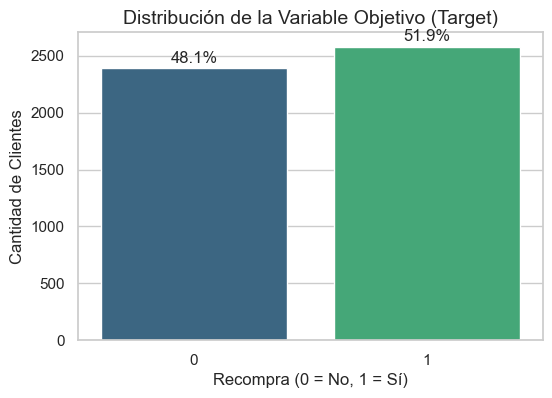

In [20]:

# Configuramos el estilo de seaborn
sns.set_theme(style="whitegrid")

# 1. Distribución del Target (Balance de Clases)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_model, x='Target', palette='viridis')
plt.title('Distribución de la Variable Objetivo (Target)', fontsize=14)
plt.xlabel('Recompra (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Clientes')

# Añadimos los porcentajes encima de las barras
total = len(df_model)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), ha='center')

plt.show()


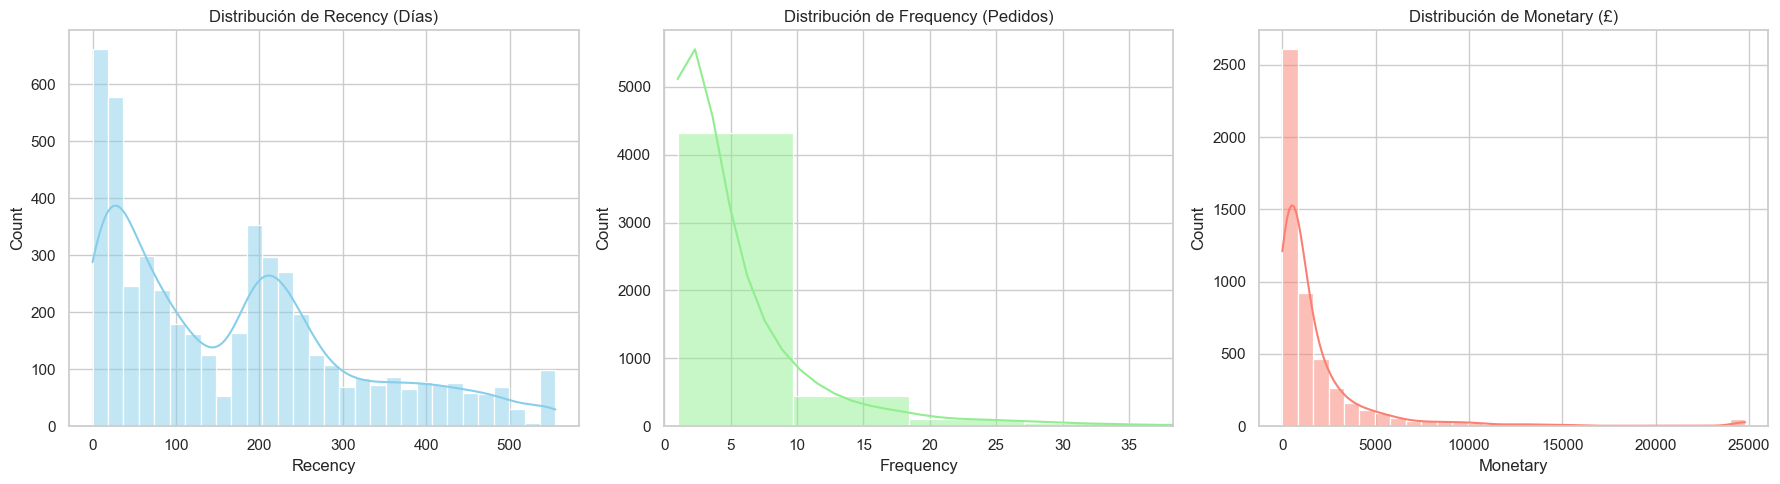

In [21]:
# 2. Distribución de Variables RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_model['Recency'], bins=30, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Distribución de Recency (Días)')

sns.histplot(df_model['Frequency'], bins=30, ax=axes[1], color='lightgreen', kde=True)
axes[1].set_title('Distribución de Frequency (Pedidos)')
axes[1].set_xlim(0, df_model['Frequency'].quantile(0.99)) # Capping visual para legibilidad

sns.histplot(df_model['Monetary'], bins=30, ax=axes[2], color='salmon', kde=True)
axes[2].set_title('Distribución de Monetary (£)')

plt.tight_layout()
plt.show()


**Interpretación de Distribuciones RFM:**

Los histogramas muestran distribuciones fuertemente asimétricas (sesgo positivo), un comportamiento típico en bases de datos de retail real. La mayoría de los clientes realizan compras infrecuentes de bajo valor monetario, mientras que una larga cola a la derecha (long-tail) identifica a una minoría de clientes VIP que acumulan altos volúmenes de gasto y transacciones.

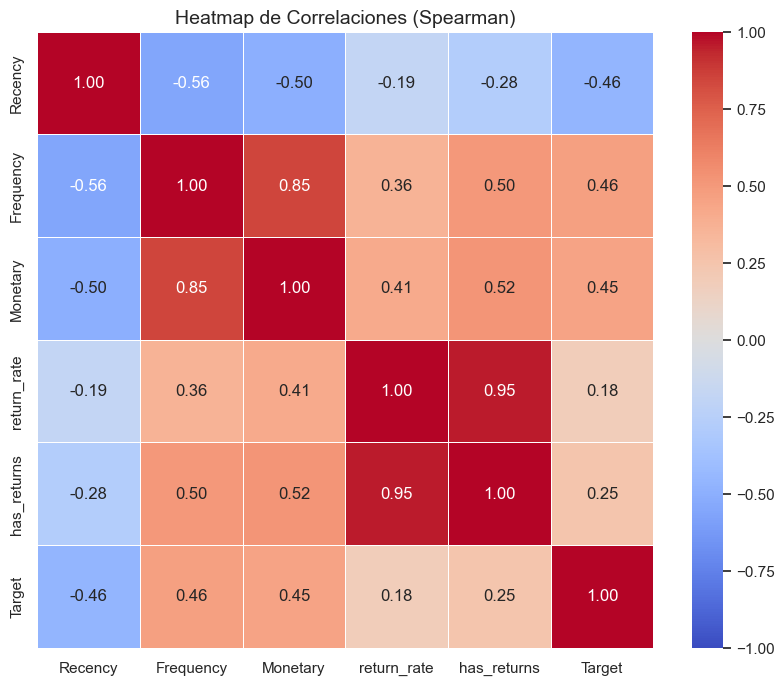

In [22]:
# 3. Heatmap de Correlación Numérica
plt.figure(figsize=(10, 8))
numeric_cols = ['Recency', 'Frequency', 'Monetary', 'return_rate', 'has_returns', 'Target']
corr_matrix = df_model[numeric_cols].corr(method='spearman') # Usamos Spearman al no ser distribuciones normales

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", square=True, linewidths=.5)
plt.title('Heatmap de Correlaciones (Spearman)', fontsize=14)
plt.show()

**Interpretación de la Matriz de Correlación:**

El mapa de calor revela las relaciones lineales entre las variables numéricas. Destaca la fuerte correlación positiva entre `Frequency` y `Monetary`, lo que confirma que el hábito de compra regular es el principal motor del ingreso total (AOV consistente). Por otro lado, variables como `Recency` muestran independencia de la cantidad gastada, aportando una dimensión predictiva separada para futuros modelos de Machine Learning.

### 7.1. Auditoría de Fuga de Datos (Anti-Leakage Check)\n
Antes de guardar el dataset, ejecutamos una prueba rigurosa para garantizar matemáticamente que las variables predictoras (RFM) no contienen información de compras que ocurrieron dentro de la ventana de predicción del Target. Esto es vital para asegurar que el modelo sea realista.

In [23]:
print("Ejecutando Auditora Anti-Leakage (Validacin Temporal)...")
max_obs_date = df_observacion['InvoiceDate'].max()

print(f"Fecha mxima en Variables Predictoras (RFM): {max_obs_date}")
print(f"Fecha de corte estricta impuesta: {fecha_corte}")

# Comprobación temporal: ningún registro de la ventana de observación debe superar la fecha de corte
if max_obs_date <= fecha_corte:
    print("\u2705 AUDITORA SUPERADA: 0 registros futuros contaminan las features del modelo.")
else:
    print("\u274c ALERTA DE LEAKAGE: Existen datos de features que sobrepasan la fecha de corte.")

# Comprobación de consistencia de IDs: aseguramos que los tipos coincidan antes del assert
if df_model['Customer ID'].dtype != df_observacion['Customer ID'].dtype:
    df_observacion['Customer ID'] = df_observacion['Customer ID'].astype(df_model['Customer ID'].dtype)

assert df_model['Customer ID'].isin(df_observacion['Customer ID']).all(), "Existen clientes en el modelo que no tienen histrico."
print("\u2705 AUDITORA SUPERADA: Todos los clientes del modelo provienen estrictamente de la cohorte histrica.")

Ejecutando Auditora Anti-Leakage (Validacin Temporal)...
Fecha mxima en Variables Predictoras (RFM): 2011-06-09 12:40:00
Fecha de corte estricta impuesta: 2011-06-09 12:50:00
✅ AUDITORA SUPERADA: 0 registros futuros contaminan las features del modelo.
✅ AUDITORA SUPERADA: Todos los clientes del modelo provienen estrictamente de la cohorte histrica.


## 8. Exportación del Dataset Maestro (Checkpoint)

Una vez finalizada la limpieza estructural, la aplicación estricta de las reglas de negocio y el proceso de ingeniería de características (*Feature Engineering*), hemos transformado exitosamente un histórico masivo de transacciones brutas en una matriz predictiva de clientes, enriquecida y libre de ruido.

Para garantizar la reproducibilidad del experimento y separar funcionalmente la tubería de procesamiento de datos (*Data Pipeline*) de la tubería de algoritmos (*Machine Learning Pipeline*), el paso definitivo de esta primera fase es materializar el DataFrame resultante (`df_model`) en un archivo físico de almacenamiento.

**Decisión Técnica de Arquitectura (Apache Parquet vs CSV):** Exportaremos el dataset utilizando el estándar columnar Apache Parquet. Esta decisión se fundamenta en dos ventajas técnicas críticas de cara a la siguiente fase:
1. **Preservación inmutable de tipos de datos:** Parquet serializa y mantiene intactas las estructuras originales de Pandas. Nuestras variables binarias (`Is_UK`, los clústeres NLP) y nuestros números enteros seguirán siéndolo. Si usáramos un archivo `.csv`, la lectura posterior obligaría a Pandas a re-inferir los tipos de datos, arriesgándonos a corromper la matriz (transformando enteros en decimales, por ejemplo).
2. **Eficiencia y compresión:** Al ser un formato binario orientado a columnas, su peso en disco es mínimo y la velocidad de ingestión en memoria para la fase de modelado es exponencialmente superior al texto plano.

Con la generación de este archivo, damos por concluido el Análisis Exploratorio y la Limpieza, dejando el terreno preparado para el Notebook 2: Modelado Predictivo de Recompra.

In [24]:

print("Guardando checkpoint del dataset maestro       ")


# Definimos la ruta de exportación absoluta basada en tu estructura
OUTPUT_DIR = r"../data/processed"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "df_model.parquet")

# Verificamos que el directorio de destino exista; si no, lo creamos
os.makedirs(OUTPUT_DIR, exist_ok=True)

try:
    # Guardamos en formato parquet (altamente eficiente y respeta los tipos de datos)
    df_model.to_parquet(OUTPUT_FILE, index=False, engine='pyarrow')
    print(f"ÉXITO: Dataset guardado correctamente en:")
    print(f"Ruta: {OUTPUT_FILE}")
    print(f"Dimensiones finales: {df_model.shape[0]:,} filas y {df_model.shape[1]} columnas.")
except Exception as e:
    print(f"ERROR al intentar guardar el archivo: {e}")
    print("Asegúrate de tener instalado pyarrow: pip install pyarrow")

Guardando checkpoint del dataset maestro       
ÉXITO: Dataset guardado correctamente en:
Ruta: ../data/processed\df_model.parquet
Dimensiones finales: 4,967 filas y 23 columnas.


### 8.1. Exportación Secundaria: Dataset Transaccional para Business Storytelling

Aunque el modelo predictivo requiere una granularidad a nivel de cliente (`df_model`), la presentación de resultados a los *Stakeholders* y al equipo de negocio exige un análisis de la evolución temporal y del rendimiento de los productos (granuralidad a nivel de ticket/factura). 

Para garantizar que en el siguiente notebook podamos extraer estos *Insights* estratégicos (como la estacionalidad de ingresos o el Top de productos "gancho") de forma ágil y sin necesidad de recalcular el archivo Excel original, procedemos a guardar una copia del dataset transaccional limpio en formato `.parquet`.

In [25]:

print("Guardando dataset transaccional (storytelling) ")


# --- ARREGLO DE TIPADO CRÍTICO PARA PARQUET ---
# Forzamos que los códigos identificadores sean texto puro para evitar colapsos
df_observacion['StockCode'] = df_observacion['StockCode'].astype(str)
df_observacion['Invoice'] = df_observacion['Invoice'].astype(str) # Corregido: Invoice en lugar de InvoiceNo

# Blindamos también el Customer ID
if 'Customer ID' in df_observacion.columns:
    df_observacion['Customer ID'] = df_observacion['Customer ID'].astype(str)
# ----------------------------------------------

# 1. Definimos la ruta relativa
OUTPUT_DIR = r"../data/processed"
OUTPUT_FILE_TRANS = os.path.join(OUTPUT_DIR, "df_transactions.parquet")

# 2. Medida de seguridad de directorios
os.makedirs(OUTPUT_DIR, exist_ok=True)

try:
    # 3. Exportación utilizando pyarrow
    df_observacion.to_parquet(OUTPUT_FILE_TRANS, index=False, engine='pyarrow')
    
    print("EXITO: Dataset transaccional guardado correctamente en:")
    print(f"Ruta: {OUTPUT_FILE_TRANS}")
    print(f"Dimensiones finales: {df_observacion.shape[0]:,} filas y {df_observacion.shape[1]} columnas.")
except Exception as e:
    print(f"ERROR al intentar guardar el archivo: {e}")

Guardando dataset transaccional (storytelling) 
EXITO: Dataset transaccional guardado correctamente en:
Ruta: ../data/processed\df_transactions.parquet
Dimensiones finales: 538,840 filas y 8 columnas.
